In [3]:
import pandas as pd
import numpy as np
import glob, os, shutil, cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [4]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted(glob.glob(os.path.join(path, '*')))
    if shuffle:
        np.random.shuffle(target) 
    return target[:limit]


images = [np.load(img) for img in getFiles('images')]
masks  = [np.load(img) for img in getFiles('masks')]

IMG_SIZE = images[0].shape[0]
images[:5]

[array([[[ 0.12120506,  0.17570351,  0.4359985 , ..., -0.4947749 ,
          -0.6476258 , -0.66195   ],
         [ 0.1122046 ,  0.38752872,  0.5579165 , ..., -0.42703027,
          -0.62235016, -0.69377184],
         [ 0.11782821,  0.5109103 ,  0.5682595 , ..., -0.37594628,
          -0.73534375, -0.94065976],
         ...,
         [-0.23042697, -0.32701367, -0.8466749 , ..., -0.59866023,
          -0.26966175,  0.6604995 ],
         [-0.3479929 , -0.4939739 , -0.6872361 , ..., -0.5468131 ,
          -0.2615065 ,  0.49023777],
         [-0.28028083, -0.5623336 , -0.76194334, ..., -0.41575906,
          -0.27286473,  0.31606558]],
 
        [[ 0.11168589,  0.20517224,  0.46182802, ..., -0.3388075 ,
          -0.73724127, -0.7908831 ],
         [ 0.03122767,  0.42496234,  0.67580825, ..., -0.23772597,
          -0.58448696, -0.7918161 ],
         [-0.00357361,  0.54627657,  0.7120623 , ..., -0.18555507,
          -0.72388   , -1.0191149 ],
         ...,
         [-0.11975164, -0.0105104

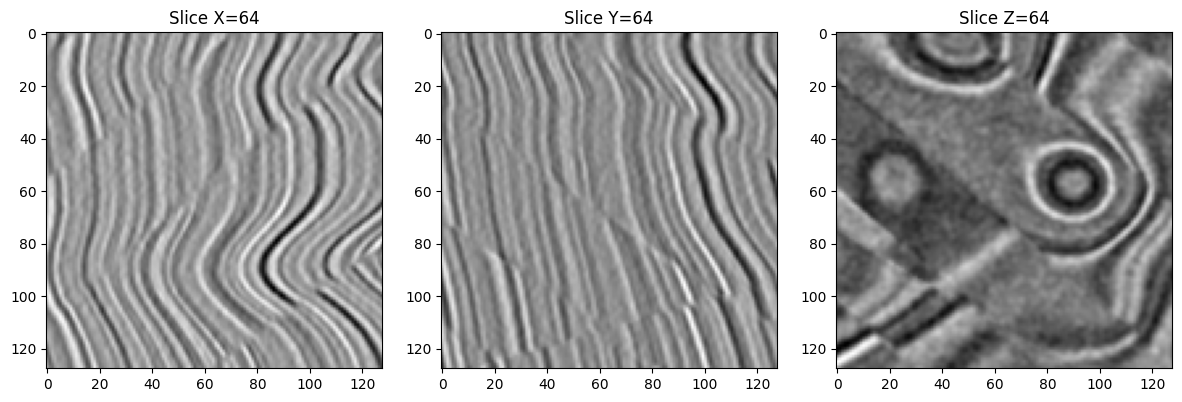

In [5]:
def showTile(img, mask=False):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    mid_x = img.shape[0] // 2
    mid_y = img.shape[1] // 2
    mid_z = img.shape[2] // 2

    slices = [
        img[mid_x, :, :],  # Plano YZ (Corte ao longo do eixo X)
        img[:, mid_y, :],  # Plano XZ (Corte ao longo do eixo Y)
        img[:, :, mid_z]   # Plano XY (Corte ao longo do eixo Z)
    ]

    cmap_config = ListedColormap(['black', 'red', 'green', 'blue']) if mask else 'gray'
    vmin, vmax  = (0, 3) if mask else (None, None)
    titles = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']
    
    for i, ax in enumerate(axes):
        ax.imshow(slices[i], cmap=cmap_config, vmin=vmin, vmax=vmax)
        ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()


showTile(images[0])

In [5]:
def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


img_path = f'../../Model/Database/Target/images'
mask_path = f'../../Model/Database/Target/masks'

setFolder(img_path)
setFolder(mask_path)

for i, (img, mask) in enumerate(zip(images, masks)):
    np.save(f"{img_path}/{i}.npy", img)
    np.save(f"{mask_path}/{i}.npy", mask)